In [1]:
from pathlib import Path

import dtreeviz
import matplotlib.pyplot as plt
import numpy as np
import optuna
import scienceplots  # noqa: F401
import torch
from sklearn.tree import DecisionTreeClassifier

from csi_vae.jobs import JobSettings, dataset, fusion, vae
from csi_vae.jobs.job import make_dataloader

settings = JobSettings()

LAUNCH_DIR = Path("../out/flat_conv_full")
WEIGHTS_DIR = Path("../weights")
PLOTS_DIR = LAUNCH_DIR / "plots"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OOD_DATASET = Path("../dataset/S1b.h5")
ACTIVITIES = [
    "Walk",
    "Run",
    "Jump",
    "Sit",
    "Empty",
    "Stand",
    "Waving",
    "Clap",
    "Lay down",
    "Wipe",
    "Squat",
    "Stretch",
]

PLOTS_DIR.mkdir(exist_ok=True)

/mnt/servicesdata/lcotti/csi-vae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
studies_files = sorted([f.name for f in LAUNCH_DIR.iterdir() if f.is_file() and f.suffix == ".sqlite"])
studies = [
    optuna.load_study(study_name=study.split(".")[0], storage=f"sqlite:///{LAUNCH_DIR / study}").trials_dataframe()
    for study in studies_files
]

best_models_per_study: list[dict] = []

for i, study in enumerate(studies):
    completed = study[study["state"] == "COMPLETE"].copy()
    study_best= {
        "n_gaussians": i + 1,
        "trial_number": 0,
        "trial_value": 0.0,
        "seed": 0,
        "best_seed_accuracy": 0.0,
        "params": {},
    }

    for _, trial in completed.iterrows():
        accuracies_per_seed = trial["user_attrs_accuracies"]

        best_seed = max(accuracies_per_seed, key=accuracies_per_seed.get)
        best_accuracy = float(accuracies_per_seed[str(best_seed)])

        if trial["value"] > study_best["trial_value"]:
            study_best = {
                "n_gaussians": i + 1,
                "trial_number": trial["number"],
                "trial_value": trial["value"],
                "seed": int(best_seed),
                "best_seed_accuracy": best_accuracy,
                "params": trial.filter(like="params_").rename(lambda x: x.replace("params_", "")).to_dict(),
            }

    best_models_per_study.append(study_best)

best_model = max(best_models_per_study, key=lambda x: x["best_seed_accuracy"])
print(
    f"Best model: n_gaussians={best_model['n_gaussians']}, "
    f"trial_number={best_model['trial_number']}, "
    f"seed={best_model['seed']}, "
    f"accuracy={best_model['best_seed_accuracy']:.4f}",
)

Best model: n_gaussians=2, trial_number=77, seed=347227206, accuracy=0.9812


In [3]:
batch_size = 2**best_model["params"]["batch_size_exp"]
train_ds, val_ds, test_ds = dataset.load(
    dataset_path=Path("../") / settings.dataset_path,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)
train_dl = make_dataloader(train_ds, batch_size=batch_size, shuffle=True, seed=best_model["seed"])
val_dl = make_dataloader(val_ds, batch_size=batch_size, shuffle=False, seed=best_model["seed"])
test_dl = make_dataloader(test_ds, batch_size=batch_size, shuffle=False, seed=best_model["seed"])

In [4]:
gaussians = [
    vae.SingleAntenna(
        settings.window_size,
        settings.n_subcarriers,
        best_model["n_gaussians"],
        vae.CONV_SPECS[best_model["params"]["conv_layers_spec"]],
    ).to(DEVICE)
    for _ in range(settings.n_antennas)
]
delayed_fusion = fusion.Delayed(
    gaussians,
    best_model["n_gaussians"],
    settings.n_activities,
    best_model["params"]["n_fusion_layers"],
    best_model["params"]["fusion_dropout"],
).to(DEVICE)

model_path = (
    WEIGHTS_DIR
    / f"l{best_model['n_gaussians']}"
    / f"t{best_model['trial_number']}"
    / f"s{best_model['seed']}"
    / "delayed_fusion.pt"
)
delayed_fusion.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [5]:
def _extract_vae_features(
    gaussians: list[vae.SingleAntenna],
    dataloader: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[np.ndarray, np.ndarray]:
    features = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            # Replicate the logic in your Delayed.forward:
            # Extract mu and logvar from each antenna
            outs = []
            for i, antenna in enumerate(gaussians):
                antenna.eval()

                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
                    _, mu, logvar = antenna(x[:, i].to(device))
                outs.append(torch.cat([mu, logvar], dim=1))

            z = torch.cat(outs, dim=1)
            features.append(z.cpu().numpy())
            labels.append(y.numpy())

    return np.concatenate(features), np.concatenate(labels)


feat_names = []
for ant_idx in range(settings.n_antennas):
    # First half for this antenna is mu
    feat_names.extend([f"$\\mu_{ant_idx}^{g_idx}$" for g_idx in range(settings.n_gaussians)])
    # Second half for this antenna is sigma
    feat_names.extend([f"$\\log\\sigma_{ant_idx}^{g_idx}$" for g_idx in range(settings.n_gaussians)])

# Prepare data
X_train, y_train = _extract_vae_features(gaussians, train_dl, DEVICE)
X_test, y_test = _extract_vae_features(gaussians, test_dl, DEVICE)

In [47]:
# Initialize and train the Tree
# We limit max_depth so the visualization is actually readable
tree_clf = DecisionTreeClassifier(
    max_depth=4, criterion="entropy", random_state=best_model["seed"]
)
tree_clf.fit(X_train, y_train)

print(f"Decision Tree Accuracy: {tree_clf.score(X_test, y_test):.4f}")

Decision Tree Accuracy: 0.8542


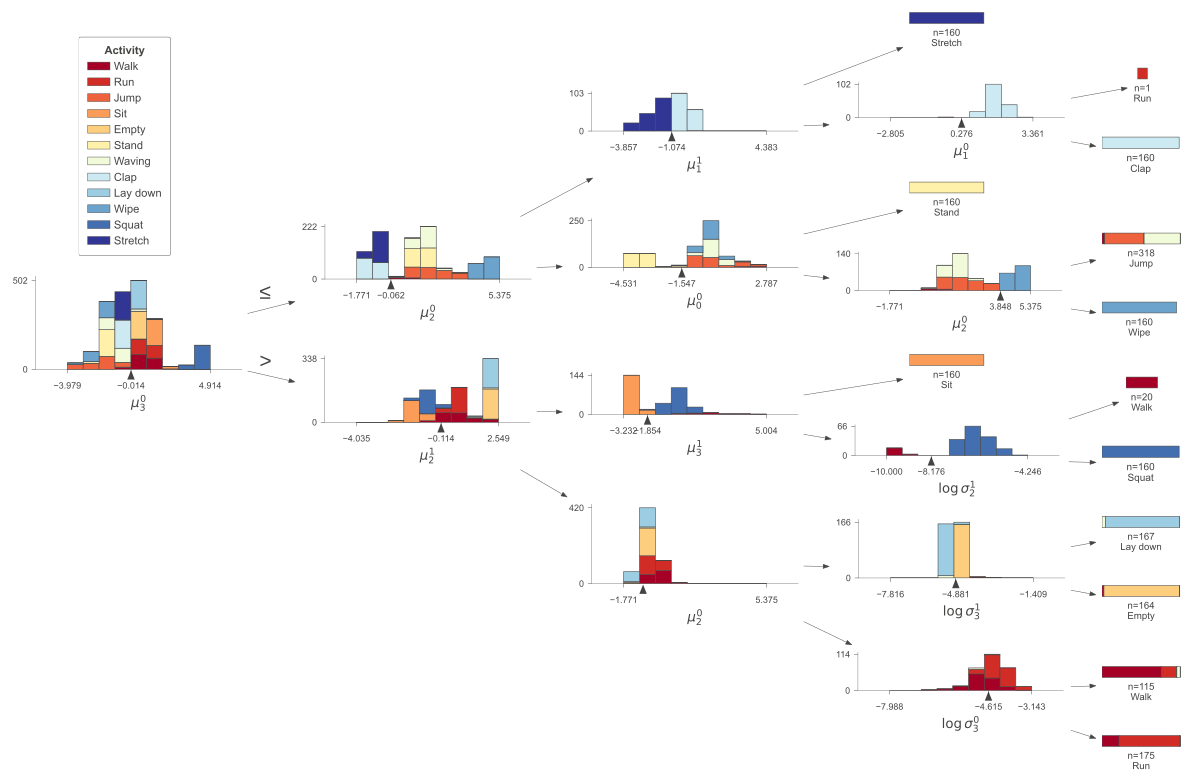

In [52]:
viz = dtreeviz.model(
    tree_clf,
    X_train=X_train,
    y_train=y_train,
    feature_names=feat_names,
    target_name="Activity",
    class_names=ACTIVITIES,
)

v = viz.view(scale=1.5, leaftype="barh", orientation="LR")
v.save(str(PLOTS_DIR / "latent_logic_tree.svg"))
v